# SIRA Project — GSoC 2026 Self-Initiated Evaluation
## Learning the SIR Epidemic Model from Stochastic Simulations

This notebook demonstrates the core pipeline for the SIRA project:
1. Stochastic simulation of the SIR model using the Gillespie algorithm
2. Dataset generation across a grid of (β, γ) parameter pairs
3. Training an MLP to predict mean S(t), I(t), R(t) from (t, β, γ)
4. Evaluating generalization to unseen parameter points

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# Imports
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import itertools



In [11]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 1: SIR MODEL DEFINITIONS
# ───────────────────────────────────────────────────────────────────────────

def sir_ode(y, t, beta, gamma):
    """Deterministic SIR ODEs — the ground truth we want the ML to recover."""
    S, I, R = y
    N = S + I + R
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

def solve_ode(N, I0, beta, gamma, t_max=160):
    """Solve the deterministic SIR ODE system."""
    S0, R0 = N - I0, 0
    t = np.linspace(0, t_max, t_max + 1)
    sol = odeint(sir_ode, [S0, I0, R0], t, args=(beta, gamma))
    return t, sol

def gillespie_sir(N, I0, beta, gamma, t_max=160, seed=None):
    """
    Gillespie (exact stochastic) simulation of SIR model.
    Two competing events:
      - Infection:  S + I → 2I  at rate beta*S*I/N
      - Recovery:   I → R        at rate gamma*I
    """
    rng = np.random.default_rng(seed)
    S, I, R = N - I0, I0, 0
    t = 0.0
    times, Ss, Is, Rs = [t], [S], [I], [R]

    while t < t_max and I > 0:
        rate_infect  = beta * S * I / N
        rate_recover = gamma * I
        total_rate   = rate_infect + rate_recover

        if total_rate == 0:
            break

        # Exponential waiting time to next event
        dt = rng.exponential(1.0 / total_rate)
        t += dt

        # Randomly select which event occurs
        if rng.random() < rate_infect / total_rate:
            S -= 1; I += 1   # infection event
        else:
            I -= 1; R += 1   # recovery event

        times.append(t)
        Ss.append(S); Is.append(I); Rs.append(R)

    return np.array(times), np.array(Ss), np.array(Is), np.array(Rs)

def run_ensemble(N, I0, beta, gamma, n_sims=200, t_max=160):
    """
    Run many stochastic simulations and return mean trajectories.
    By the Law of Large Numbers, mean → deterministic ODE as n_sims → ∞.
    """
    t_grid = np.arange(0, t_max + 1, dtype=float)
    S_all, I_all, R_all = [], [], []

    for seed in range(n_sims):
        times, Ss, Is, Rs = gillespie_sir(N, I0, beta, gamma, t_max, seed)
        # Interpolate stochastic trajectory onto uniform integer time grid
        S_all.append(np.interp(t_grid, times, Ss))
        I_all.append(np.interp(t_grid, times, Is))
        R_all.append(np.interp(t_grid, times, Rs))

    return t_grid, np.array(S_all), np.array(I_all), np.array(R_all)



## Section 2: Sanity Check
Verify that the mean of many stochastic simulations converges to the 
deterministic ODE solution — the Law of Large Numbers in action.
Expected: colored mean line should closely track the black dashed ODE.

Running 200 stochastic simulations for sanity check...


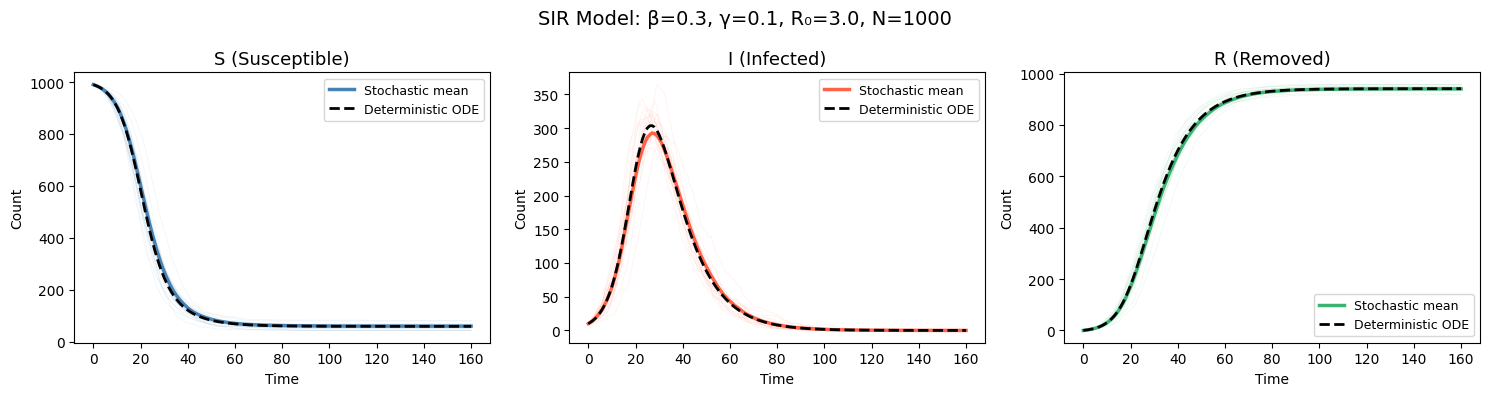

Sanity check done.



In [13]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 2: SANITY CHECK — One parameter point, stochastic mean vs ODE
# ───────────────────────────────────────────────────────────────────────────

N, I0 = 1000, 10
beta_demo, gamma_demo = 0.3, 0.1

print("Running 200 stochastic simulations for sanity check...")
t_grid, S_all, I_all, R_all = run_ensemble(N, I0, beta_demo, gamma_demo, n_sims=200)
t_ode, ode_sol = solve_ode(N, I0, beta_demo, gamma_demo)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, ode, label, color in zip(
    axes,
    [S_all, I_all, R_all],
    ode_sol.T,
    ['S (Susceptible)', 'I (Infected)', 'R (Removed)'],
    ['steelblue', 'tomato', 'mediumseagreen']
):
    for traj in data[::10]:
        ax.plot(t_grid, traj, color=color, alpha=0.08, linewidth=0.6)
    ax.plot(t_grid, data.mean(axis=0), color=color, linewidth=2.5, label='Stochastic mean')
    ax.plot(t_ode, ode, 'k--', linewidth=2, label='Deterministic ODE')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Time'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle(f'SIR Model: β={beta_demo}, γ={gamma_demo}, R₀={beta_demo/gamma_demo:.1f}, N={N}', fontsize=14)
plt.tight_layout()
plt.savefig('sir_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sanity check done.\n")



## Section 3: Dataset Generation
We simulate epidemics across a 6×6 grid of (β, γ) values, keeping only
pairs where R₀ = β/γ > 1 (epidemic threshold). Each parameter point
contributes 161 time steps, giving ~5000 training examples total.
The ML task: learn the mapping (t, β, γ) → (S, I, R) without ever 
seeing the ODE equations.

In [15]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 3: DATASET GENERATION
# Grid of (beta, gamma) pairs → simulate → store mean trajectories
# ───────────────────────────────────────────────────────────────────────────

N_SIMS = 150
T_MAX  = 160

betas  = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
gammas = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]

# Keep only epidemic cases: R0 = beta/gamma > 1
param_pairs = [(b, g) for b, g in itertools.product(betas, gammas) if b/g > 1.0]
print(f"Parameter grid: {len(param_pairs)} (β, γ) pairs")

dataset_rows = []
print("Generating dataset (≈2-3 minutes on CPU)...")

for beta, gamma in tqdm(param_pairs):
    t_grid, S_all, I_all, R_all = run_ensemble(N, I0, beta, gamma,
                                                n_sims=N_SIMS, t_max=T_MAX)
    S_mean = S_all.mean(axis=0)
    I_mean = I_all.mean(axis=0)
    R_mean = R_all.mean(axis=0)

    for i, t in enumerate(t_grid):
        dataset_rows.append([t, beta, gamma, S_mean[i], I_mean[i], R_mean[i]])

dataset = np.array(dataset_rows)
print(f"Dataset shape: {dataset.shape}")
# Expected: (~4500-5500 rows, 6 columns)

# ── Normalize ────────────────────────────────────────────────────────────────
# t → [0,1] by dividing by T_MAX
# S, I, R → [0,1] by dividing by N
# beta, gamma are already small floats, kept as-is

X = np.stack([dataset[:, 0] / T_MAX,   # t (normalized)
              dataset[:, 1],            # beta
              dataset[:, 2]], axis=1).astype(np.float32)

Y = np.stack([dataset[:, 3] / N,       # S/N
              dataset[:, 4] / N,        # I/N
              dataset[:, 5] / N], axis=1).astype(np.float32)

# Train/Val split (80/20, shuffled)
n = len(X)
idx = np.random.permutation(n)
split = int(0.8 * n)
X_train, X_val = X[idx[:split]], X[idx[split:]]
Y_train, Y_val = Y[idx[:split]], Y[idx[split:]]
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}\n")

Parameter grid: 33 (β, γ) pairs
Generating dataset (≈2-3 minutes on CPU)...


100%|███████████████████████████████████████████| 33/33 [00:12<00:00,  2.68it/s]

Dataset shape: (5313, 6)
Train: (4250, 3)  |  Val: (1063, 3)



## Section 4 & 5: MLP Architecture and Training
A 4-layer MLP with Tanh activations maps (t, β, γ) → (S/N, I/N, R/N).
- Tanh chosen for smooth approximation of continuous physical functions
- Sigmoid output enforces [0,1] range (normalized counts)
- Cosine annealing LR schedule for stable convergence

In [17]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 4: MLP MODEL DEFINITION
# ───────────────────────────────────────────────────────────────────────────

class SIRMLP(nn.Module):
    """
    Multilayer Perceptron: (t, beta, gamma) → (S/N, I/N, R/N)
    
    Architecture:
      - 4 hidden layers of 128 neurons each
      - Tanh activations (smooth, suitable for continuous physical functions)
      - Sigmoid output (enforces outputs in [0,1])
    """
    def __init__(self, hidden=128, depth=4):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 3), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SIRMLP(hidden=128, depth=4).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(Y_val))
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=512)

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)
loss_fn   = nn.MSELoss()

Device: cpu
Parameters: 50,435



Training MLP...
Epoch  50 | Train MSE: 0.001420 | Val MSE: 0.001357
Epoch 100 | Train MSE: 0.000439 | Val MSE: 0.000402
Epoch 150 | Train MSE: 0.000147 | Val MSE: 0.000154
Epoch 200 | Train MSE: 0.000085 | Val MSE: 0.000086
Epoch 250 | Train MSE: 0.000065 | Val MSE: 0.000064
Epoch 300 | Train MSE: 0.000062 | Val MSE: 0.000060


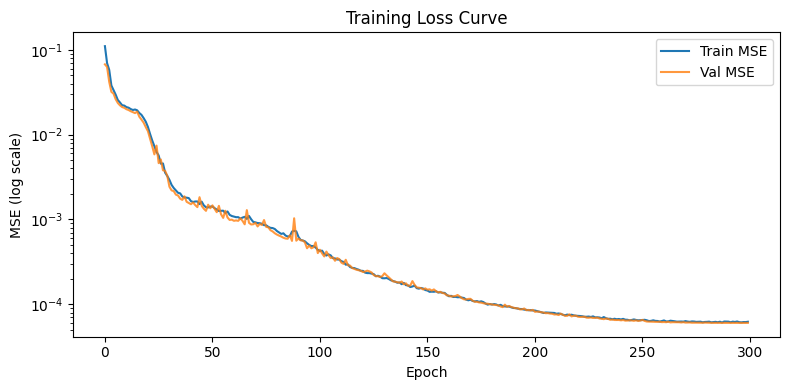

In [19]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 5: TRAINING
# ───────────────────────────────────────────────────────────────────────────

EPOCHS = 300
train_losses, val_losses = [], []

print("Training MLP...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        vl = [loss_fn(model(xb.to(device)), yb.to(device)).item()
              for xb, yb in val_dl]
    val_losses.append(np.mean(vl))
    scheduler.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train MSE: {train_losses[-1]:.6f} "
              f"| Val MSE: {val_losses[-1]:.6f}")

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE', alpha=0.8)
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('MSE (log scale)')
plt.title('Training Loss Curve')
plt.legend(); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print()

## Section 6: Evaluation on Unseen Parameters
Critical test: these 4 (β, γ) pairs were **not** in the training grid.
The MLP must generalize — it cannot have memorized these curves.

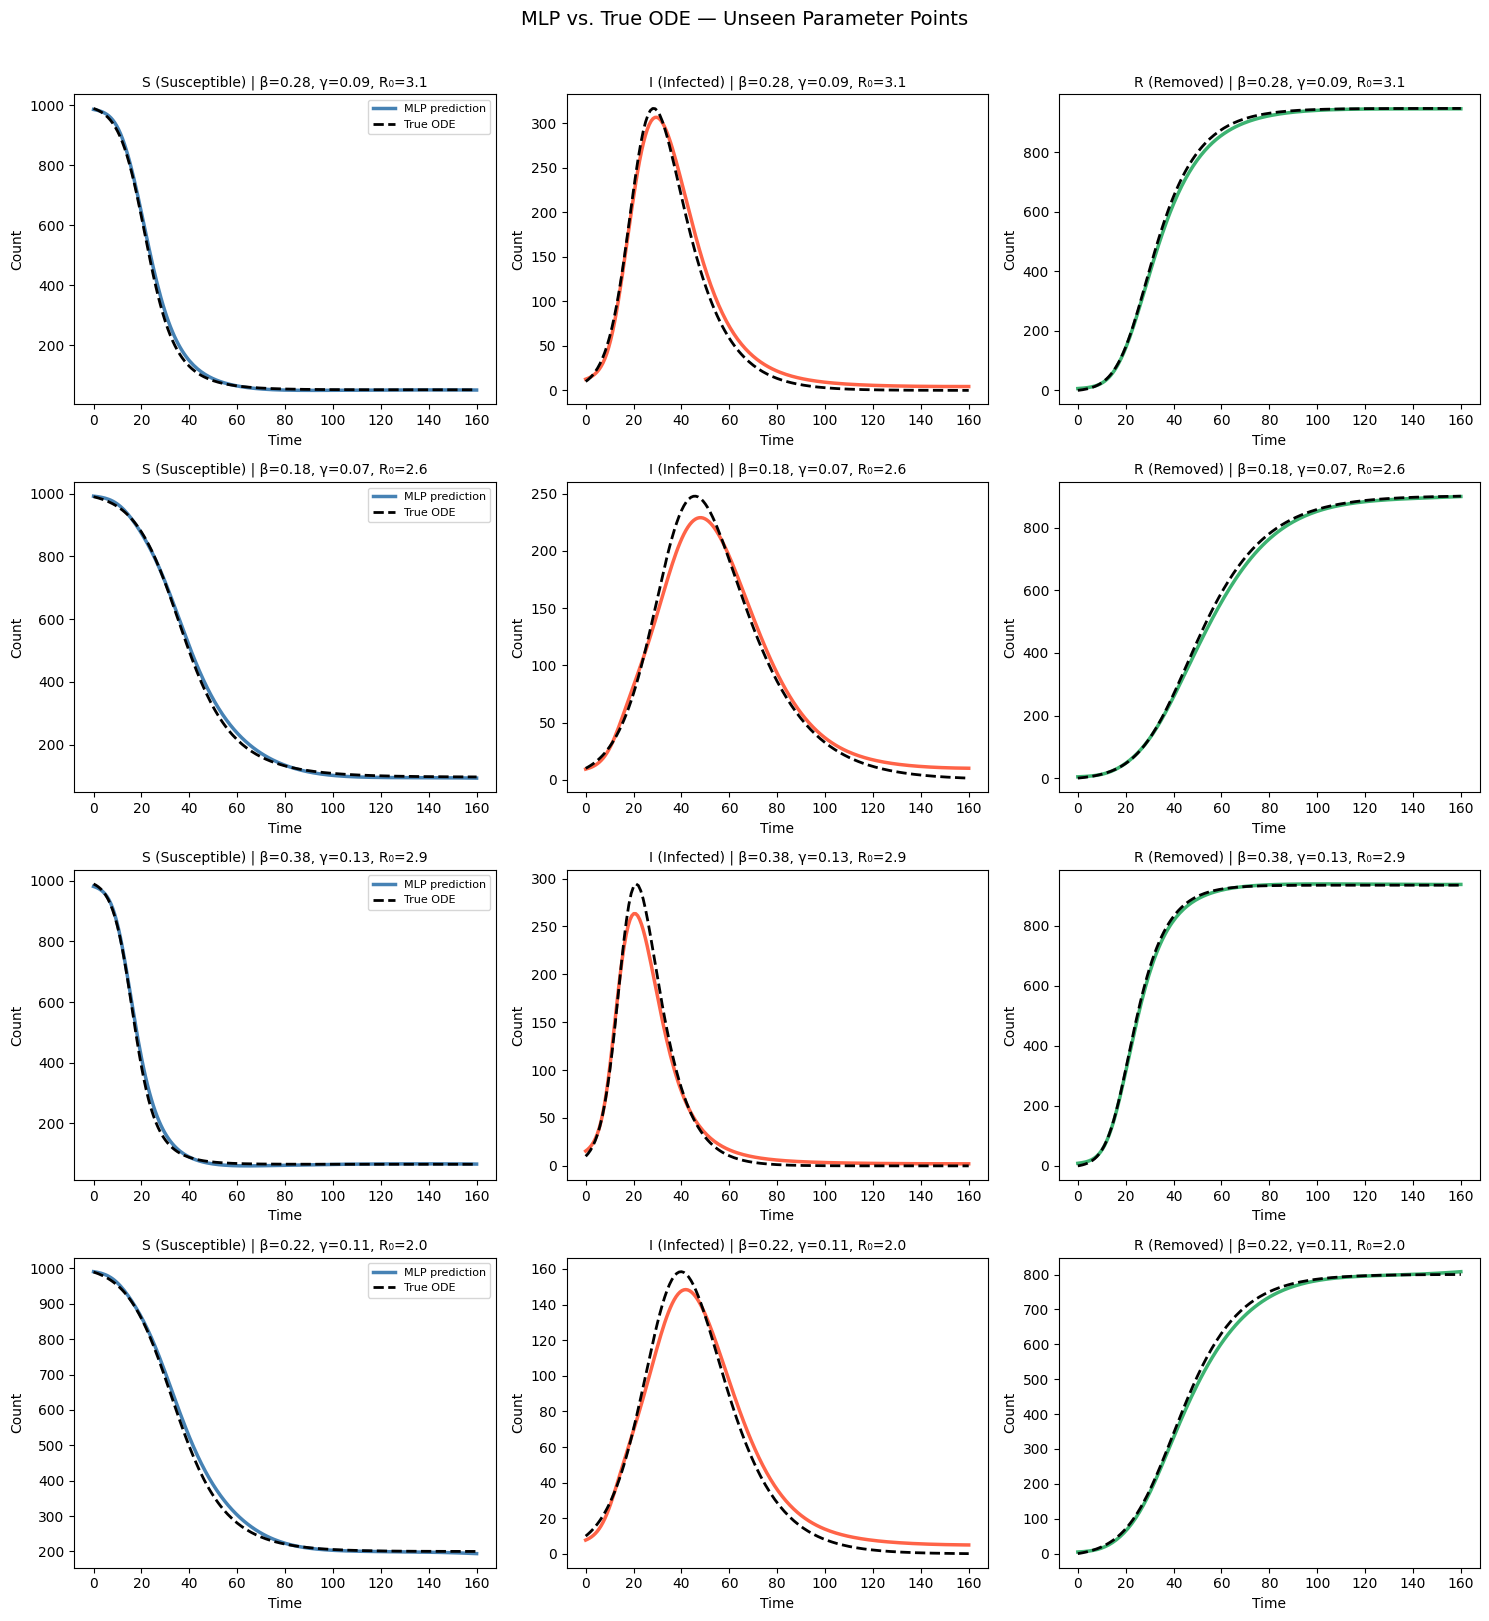

In [21]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 6: EVALUATION ON UNSEEN PARAMETER POINTS
# These (beta, gamma) values were NOT in the training grid
# ───────────────────────────────────────────────────────────────────────────

test_params = [
    (0.28, 0.09),   # R0 ≈ 3.1
    (0.18, 0.07),   # R0 ≈ 2.6
    (0.38, 0.13),   # R0 ≈ 2.9
    (0.22, 0.11),   # R0 ≈ 2.0
]

fig, axes = plt.subplots(len(test_params), 3, figsize=(15, 4 * len(test_params)))
t_test = np.linspace(0, T_MAX, 200)
model.eval()

for row, (beta, gamma) in enumerate(test_params):
    # Build input tensor for this (beta, gamma) over all time points
    X_test_np = np.stack([
        t_test / T_MAX,
        np.full_like(t_test, beta),
        np.full_like(t_test, gamma)
    ], axis=1).astype(np.float32)

    with torch.no_grad():
        preds = model(torch.from_numpy(X_test_np).to(device)).cpu().numpy()

    S_pred = preds[:, 0] * N
    I_pred = preds[:, 1] * N
    R_pred = preds[:, 2] * N

    t_ode, ode_sol = solve_ode(N, I0, beta, gamma, t_max=T_MAX)

    for col, (pred, ode, label, color) in enumerate(zip(
        [S_pred, I_pred, R_pred],
        ode_sol.T,
        ['S (Susceptible)', 'I (Infected)', 'R (Removed)'],
        ['steelblue', 'tomato', 'mediumseagreen']
    )):
        ax = axes[row, col]
        ax.plot(t_test, pred, color=color, linewidth=2.5, label='MLP prediction')
        ax.plot(t_ode,  ode,  'k--',       linewidth=2,   label='True ODE')
        ax.set_title(f'{label} | β={beta}, γ={gamma}, R₀={beta/gamma:.1f}', fontsize=10)
        ax.set_xlabel('Time'); ax.set_ylabel('Count')
        if col == 0:
            ax.legend(fontsize=8)

plt.suptitle('MLP vs. True ODE — Unseen Parameter Points', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('mlp_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ───────────────────────────────────────────────────────────────────────────
# SECTION 7: QUANTITATIVE ERROR SUMMARY
# ───────────────────────────────────────────────────────────────────────────

print("\n── Quantitative Error on Unseen Parameters ──")
print(f"{'(β, γ)':<18} {'R0':>5}  {'MAE_S':>8} {'MAE_I':>8} {'MAE_R':>8}")
print("-" * 52)

for beta, gamma in test_params:
    X_test_np = np.stack([
        t_test / T_MAX,
        np.full_like(t_test, beta),
        np.full_like(t_test, gamma)
    ], axis=1).astype(np.float32)

    with torch.no_grad():
        preds = model(torch.from_numpy(X_test_np).to(device)).cpu().numpy() * N

    t_ode, ode_sol = solve_ode(N, I0, beta, gamma, t_max=T_MAX)
    ode_interp = np.column_stack([
        np.interp(t_test, t_ode, ode_sol[:, k]) for k in range(3)
    ])

    mae_S = np.mean(np.abs(preds[:, 0] - ode_interp[:, 0]))
    mae_I = np.mean(np.abs(preds[:, 1] - ode_interp[:, 1]))
    mae_R = np.mean(np.abs(preds[:, 2] - ode_interp[:, 2]))

    print(f"(β={beta}, γ={gamma})  "
          f"R0={beta/gamma:.1f}  "
          f"MAE_S={mae_S:6.2f}  MAE_I={mae_I:6.2f}  MAE_R={mae_R:6.2f}")


── Quantitative Error on Unseen Parameters ──
(β, γ)                R0     MAE_S    MAE_I    MAE_R
----------------------------------------------------
(β=0.28, γ=0.09)  R0=3.1  MAE_S=  6.18  MAE_I=  8.03  MAE_R=  8.04
(β=0.18, γ=0.07)  R0=2.6  MAE_S=  7.89  MAE_I=  7.69  MAE_R=  8.86
(β=0.38, γ=0.13)  R0=2.9  MAE_S=  5.46  MAE_I=  5.80  MAE_R=  5.24
(β=0.22, γ=0.11)  R0=2.0  MAE_S=  8.67  MAE_I=  6.06  MAE_R=  9.07
